In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from tqdm import tqdm
import sys
import math
from scipy.integrate import solve_ivp
from multiprocessing import Pool

# Theory

The weight update rule is:

$$

\tau \frac{dw}{dt} = w(1-w)(\bar w - w) + \gamma_p (1-w) \Theta[c(t) - \theta_p] - \gamma_d w \Theta[c(t) - \theta_d]

$$

where $\bar w = 0.5$.

The post-synaptic calcium dynamics is very simple: for each pre-synaptic spike an amount of calcium $C_{pre}$ enters the synapse (with a delay $D$); for each post-synaptic spike an amount of calcium $C_{post}$ enters the synapse. Of course there is exponential decay. So:

$$
\frac{dc}{dt} = - \frac{c}{\tau_{Ca}} + C_{pre} \sum_i{\delta(t-t_i-D)} + C_{post}\sum_j{\delta(t-t_j)} 
$$

## Model implementation

In [2]:
# Calcium dynamics
tauCa = 0.02
Cpre = 1
Cpost= 2

# Weight dynamics
wstar = 0.5
tau_w= 150 
# in brunel's paper they use 3000ms, which are 3s; but they add an epsilon in front of w(1-w)(0.5-w), which is 0.02, and 3/0.02=150
# we do not put epsilon, so is good, but the other constants need to be adapted
# since now tau=150 instead of 3, we need to multiply the other constants in such a way that factor*constant/150 = constant/3. The factor is thus 150/3=50.
# but for the sigma things might be different, because we need to consider the whole factor sigma*sqrt(tau)
# so we want that sigma*sqrt(3)/3 = factor*sigma*sqrt(150)/150, thus the factor is 7.07106. 

gammaD = 200     # brunels simulation use this divided by 50, because they add an epsilon
gammaP = 321.808

thetaD = 1.
thetaP = 1.3

sigma = 2.8284  # in brunel's simulation they use 0.4, which is sigma/7.071

# Stimulation protocol to measure STDP curves
Delta_t = 0.02 # time difference between post and pre synaptik spike, in seconds
t_start = 0.5
rate = 4 # Hz, frequency of the spike pairs presentation
n_presentations = 60

# Parameters for analysis
init_down = 0.5 # fraction of synapses in the down state initially (beta in the supplementary material)
cond_up   = 5 # ratio w1/w0 (b in the supplementary material)

In [3]:
def dwdt(t, w, calcium_array, random_normal):

    x = -w*(1-w)*(wstar-w) 

    c = calcium(t, calcium_array)

    if c>thetaP:
        x += gammaP*(1-w) 

    if c>thetaD:
        x += -gammaD*w + sigma*np.sqrt(tau_w)*random_normal[times<=t][-1]/np.sqrt(dt)

    return x/tau_w


def get_calcium_array(times, pre_spike_times, post_spike_times):

    x = np.zeros(times.shape)

    for i, t in enumerate(times):
        
        x[i] = Cpost*np.sum(np.exp(-(t - post_spike_times[post_spike_times<=t] )/tauCa)) + Cpre*np.sum(np.exp(-(t - pre_spike_times[pre_spike_times<=t] )/tauCa))
    
    return x

def calcium(t, calcium_array):

    return calcium_array[times<=t][-1]

## Calcium Dynamics

In [2]:
tauCa = 0.02
Cpre = 2
Cpost = 3
thetaP = 1.3
thetaD = 1.
D = 18

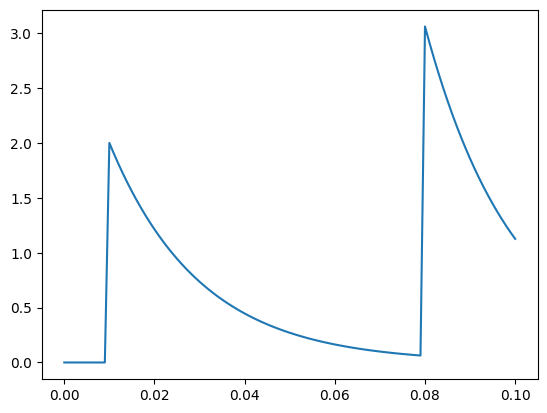

In [64]:
T = 0.1
dt = 1e-3

times = np.arange(0, T+dt, dt)

pre_spike_times = np.array([0.01])
post_spike_times = np.array([0.08])
plt.plot(times, get_ct(times, pre_spike_times, post_spike_times))


## Time spent above threshold

In [6]:
# To get the continuous curve like in the paper (numerically), we need to increase the 
# time resolution to 0.1ms. At this point we have to choose how much a spike lasts. 
# In the paper they use 1ms.
Cpre = np.linspace (0, 4, 100)

T = 100 # ms
dt = 0.1

# Pre-synapti spike at time t=10ms
spikes = np.zeros(T)
spikes[9] = 1
delayed_spikes = np.roll(spikes, D)# delayed of D=18ms
delayed_spikes[:D] = 0


times_p = []
times_d = []

for cpre in Cpre:

    c = 0
    time_above_p = 0
    time_above_d = 0

    for t in range(T): # 1ms per iteration
        
        for i in range(10): # 0.1 ms per iteration

            if c>thetaP:
                time_above_d += 0.1
                time_above_p += 0.1
            elif c>thetaD:
                time_above_d += 0.1
            
            dc = dcdt(c, tauCa, cpre, Cpost, delayed_spikes[t], 0)*dt
            c += dc
    
    times_p.append(time_above_p)
    times_d.append(time_above_d)

plt.figure(figsize=(5, 3))
plt.plot(Cpre, np.array(times_p)/T)
plt.plot(Cpre, np.array(times_d)/T)


# Let's also superpose the analytical solution
def alpha_p(cpre):

    if cpre<thetaP:
        return 0
    else:
        return tauCa*np.log(cpre/thetaP)
    
def alpha_d(cpre):

    if cpre<thetaD:
        return 0
    else:
        return tauCa*np.log(cpre/thetaD)
    
plt.plot(Cpre, np.array([alpha_p(x) for x in Cpre])/T)
plt.plot(Cpre, np.array([alpha_d(x) for x in Cpre])/T)

NameError: name 'dcdt' is not defined

## Examples

In [ ]:
w0 = 0.5
tauCa = 0.02 # in sec
Cpre = 3
Cpost = 2.
thetaD  = 1.
thetaP  = 1.3
gammaD  = 200.
gammaP  = 321.808
sigma   = 2.8284
tau     = 150.
D       = 0.0137 # in sec

In [ ]:
T = 120 # s
dt = 0.001 # s

steps = int(T/dt)

c = 0
w = 0

w_list = []
c_list = []

spike_times = np.arange(10, 70, 1) # spike times in sec
spike_steps = spike_times/dt
spike_count = 0

for i in tqdm(range(steps)):

    w_list.append(w)
    c_list.append(c)

    if i==spike_steps[spike_count]:
        spike_count += (spike_count<len(spike_times)-1)
        delayed_spike_pre = True
    else:
        delayed_spike_pre = False

    dw = compute_dw(w, c, tau, gammaP, thetaP, gammaD, thetaD, w0, dt) + noise(c, thetaP, thetaD, sigma, tau, dt)
    dc = compute_dc(c, tauCa, Cpre, Cpost, delayed_spike_pre, 0, dt)

    c += dc
    w += dw 

100%|██████████| 120000/120000 [00:00<00:00, 1063761.19it/s]


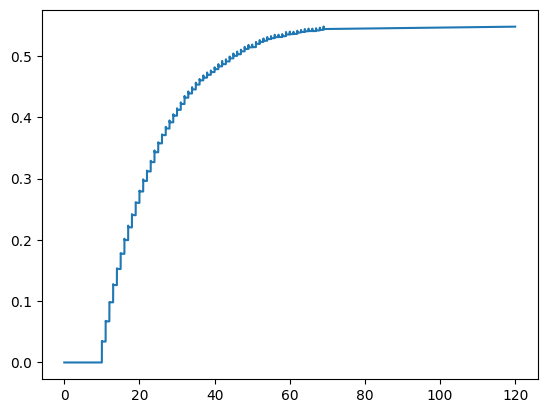

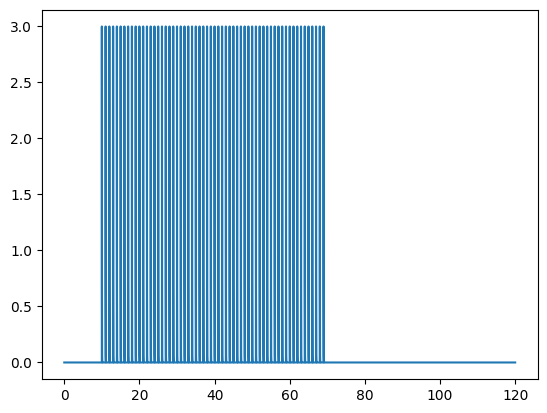

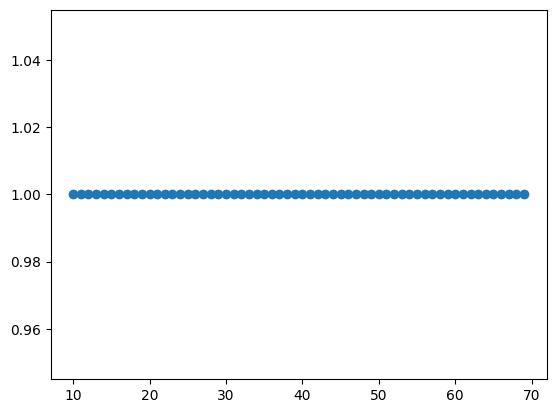

In [ ]:
plt.figure()
plt.plot(np.arange(0, T, dt), w_list)

plt.figure()
plt.plot(np.arange(0, T, dt), c_list)

## STDP Curve - DP

### Functions for the analytic solution

In [7]:
from numpy import fabs, exp, log, zeros, NaN

def timeAboveThreshold(deltaT,frequency, tauCa, Cpre, Cpost, thetaD, thetaP, **kwargs):
                
        interval = 1./frequency
        
        timeAbove = zeros(2)
        
        # in case deltaT is larger then one interval
        if (fabs(deltaT) > 1./frequency ):
                deltaT = -(fabs(deltaT) - 1./frequency)
        
        # determine amplitude of the discontinous points of the calcium trace
        # post-pre
        if ( exp(1./(frequency*tauCa)) == NaN ) :
                A = 0.
                B = Cpost*exp(-fabs(deltaT)/tauCa)
        else :
                A  = (Cpost + Cpre*exp(fabs(deltaT)/tauCa))/(exp(1./(frequency*tauCa)) - 1.)
                B  = (Cpre + Cpost*exp((1./frequency -fabs(deltaT))/tauCa))/(exp(1./(frequency*tauCa)) - 1.)
        C  = A + Cpost
        D  = B + Cpre

        # pre-post
        if ( exp(1./(frequency*tauCa)) == NaN ) :
                E = 0.
                F = Cpre*exp(-fabs(deltaT)/tauCa)
        else :
                E  = (Cpre + Cpost*exp(fabs(deltaT)/tauCa))/(exp(1./(frequency*tauCa)) - 1.)
                F  = (Cpost + Cpre*exp((1./frequency -fabs(deltaT))/tauCa))/(exp(1./(frequency*tauCa)) - 1.)
                
        G  = E + Cpre
        H  = F + Cpost
        
        # loop over depression and potentiation threshold
        for i in range(2):
                if i == 0:
                        Ct = thetaD
                elif i==1:
                        Ct = thetaP
                # post-pre
                if (deltaT < 0.):
                        if ( A <= Ct and B > Ct ) :
                                I = tauCa*log(D/Ct) + fabs(deltaT)
                        elif ( A > Ct and B > Ct) :
                                I = 1./frequency
                        elif ( A > Ct and B <= Ct ) :
                                I = tauCa*log(C/Ct) + fabs(1./frequency) - fabs(deltaT)
                        elif ( A <= Ct and B <= Ct and D > Ct and C > Ct ) :
                                I = tauCa*log(C/Ct) + tauCa*log(D/Ct)
                        elif ( A <= Ct and B <= Ct and D <= Ct and C > Ct ) :
                                I = tauCa*log(C/Ct)
                        elif( A <= Ct and B <= Ct and D > Ct and C <= Ct ) :
                                I = tauCa*log(D/Ct)
                        elif ( A <= Ct and B <= Ct and D <= Ct and C <= Ct ) :
                                I = 0.
                        else :
                                print(A, B, C, D, Ct, frequency, deltaT)
                                print("post-pre : Problem in spikePairFrequency!")
                                sys.exit(1)
                # pre-post
                else:
                        if ( E <= Ct and F > Ct ) :
                                I = tauCa*log(H/Ct) + fabs(deltaT)
                        elif ( E > Ct and F > Ct) :
                                I = 1./frequency
                        elif ( E > Ct and F <= Ct ) :
                                I = tauCa*log(G/Ct) + fabs(1./frequency) - fabs(deltaT)
                        elif ( E <= Ct and F <= Ct and G > Ct and H > Ct ) :
                                I = tauCa*log(G/Ct) + tauCa*log(H/Ct)
                        elif ( E <= Ct and F <= Ct and H <= Ct and G > Ct ) :
                                I = tauCa*log(G/Ct)
                        elif ( E <= Ct and F <= Ct and H > Ct and G <= Ct ) :
                                I = tauCa*log(H/Ct)
                        elif ( E <= Ct and F <= Ct and G <= Ct and H <= Ct ) :
                                I = 0.
                        else :
                                print(E, F, G, H, Ct, frequency, deltaT)
                                print("pre-post : Problem in spikePairFrequency! ")
                                sys.exit(1)
                #
                timeAbove[i] = I
        #
        alphaD = timeAbove[0]/interval
        alphaP = timeAbove[1]/interval
        return (alphaD,alphaP)

def transitionProbability(T_total, rho0, rhoBar,sigmaRhoSquared,tauEff, rhoStar):

    # argument for the Error Function
    x1 =  -(rhoStar - rhoBar + (rhoBar - rho0)*np.exp(-T_total/tauEff))/(np.sqrt(sigmaRhoSquared*(1.-np.exp(-2.*T_total/tauEff))))
    # transition probability
    if rho0 == 0.:
        return (1. + math.erf(x1))/2.
    else:
        return (1. - math.erf(x1))/2.

def changeInSynapticStrength(T_total,rho0,alphaD,alphaP, gammaP, gammaD, tau, beta, sigma, rhoStar, b, **kwargs):
    
    # fraction of time spent above threshold
    (alphaD,alphaP) = (alphaD, alphaP)
    
    # average potentiation and depression rates
    GammaP = gammaP*alphaP
    GammaD = gammaD*alphaD
    
    # rhoBar: average value of rho in the limit of a very long protocol equivalent to the minimum of the quadratic potentia
    rhoBar = GammaP/(GammaP + GammaD)
    
    # sigmaRhoSquared L standard deviation of rho in the same limit
    sigmaRhoSquared = (alphaP + alphaD)*(sigma**2)/(GammaP + GammaD)
    # tauEff : characteristic time scale of the temporal evolution of the pdf of rho
    tauEff = tau/(GammaP + GammaD)
    #
    # UP and the DOWN transition probabilities
    UP   = transitionProbability(T_total,0.,rhoBar,sigmaRhoSquared,tauEff, rhoStar)
    DOWN = transitionProbability(T_total,1.,rhoBar,sigmaRhoSquared,tauEff, rhoStar)
    
    # mean value of the synaptic strength right at the end of the stimulation protocol
    meanUP   =  rhoBar - (rhoBar - 0.)*np.exp(-T_total/tauEff)
    meanDOWN =  rhoBar - (rhoBar - 1.)*np.exp(-T_total/tauEff)
    mean     =  rhoBar - (rhoBar - rho0)*np.exp(-T_total/tauEff)
    
    # change in synaptic strength after/before
    synChange = ((beta*(1.-UP) + (1.-beta)*DOWN) + (beta*UP+ (1.-beta)*(1.-DOWN))*b)/(beta + (1.-beta)*b)

    return meanUP, meanDOWN, synChange

### Analytic solution

In [8]:
named_parameters = {'DP':{'tauCa':0.02,'Cpre':1.,'Cpost':2.,'thetaD':1.,'thetaP':1.3,'gammaD':200.,'gammaP':321.808,'sigma':2.8284,'tau':150.,'rhoStar':0.5,'D':0.0137,'beta': 0.5,'b': 5.},
                   'DPD':{'tauCa':0.02,'Cpre':0.9,'Cpost':0.9,'thetaD':1.,'thetaP':1.3,'gammaD':250.,'gammaP':550.,'sigma' :2.8284,'tau':150.,'rhoStar':0.5,'D':0.0046,'beta': 0.5,'b': 5.},
                    'DPDprime':{'tauCa':0.02,'Cpre':1.,'Cpost':2.,'thetaD':1.,'thetaP':2.5,'gammaD':50.,'gammaP':600.,'sigma':2.8284,'tau':150.,'rhoStar':0.5,'D ':0.0022,'beta': 0.5,'b': 5.},
                     'P':{'tauCa':0.02,'Cpre':2.,'Cpost':2.,'thetaD':1.,'thetaP':1.3,'gammaD':160.,'gammaP':257.447,'sigma':2.8284,'tau':150.,'rhoStar':0.5,'D':0.0,'beta': 0.5,'b': 5.},
                     'D':{'tauCa':0.02,'Cpre':0.6,'Cpost':0.6,'thetaD':1.,'thetaP':1.3,'gammaD':500.,'gammaP':550.,'sigma' :5.6568,'tau':150.,'rhoStar':0.5,'D':0.,'beta': 0.5,'b': 5.},
                    'Dprime':{'tauCa':0.02,'Cpre':1.,'Cpost':2.,'thetaD':1.,'thetaP':3.5,'gammaD':60.,'gammaP':600.,'sigma':2.8284,'tau' : 150.,'rhoStar':0.5,'D':0., 'beta': 0.5,'b': 5.}
                    }

curve = 'DP'

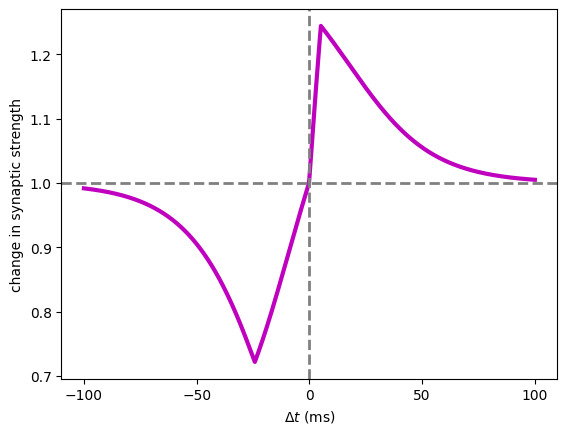

In [9]:
# Parameter of the stimulation protocol
frequency   = 1.    # frequency of spike-pair presentations in Hz
interval    = 1./frequency
N           = 60.     # number of spike-pair presentations
DeltaTstart = -0.1    # start time difference between pre- and post-spike, in sec
DeltaTend   =  0.1    # end time difference between pre- and post-spike, in sec
DeltaTsteps =  2000  # steps between start and end value

deltaT = np.linspace(DeltaTstart,DeltaTend,DeltaTsteps+1)

sChanges  = []
meanUPs   = []
meanDOWNs = []
alphaDs   = []
alphaPs   = []

# loop over range of deltaT values
for i in deltaT:
        
        # fraction of time spent above threshold
        alphaD, alphaP = timeAboveThreshold(i-named_parameters[curve]['D'],frequency, **named_parameters[curve])

        # calculate all values for the change in synaptic strength
        meanUP, meanDOWN, sChange = changeInSynapticStrength(N*interval,0.5,alphaD,alphaP, **named_parameters[curve])
        
        alphaDs.append(alphaD)
        alphaPs.append(alphaP)

        # mean value of the synaptic strength right at the end of the stimulation protocol
        meanUPs.append(meanUP)
        meanDOWNs.append(meanDOWN)
        
        # change in synaptic strength after/before
        sChanges.append(sChange)

fig, ax = plt.subplots()

ax.set_ylabel('change in synaptic strength')
ax.set_xlabel(r'$\Delta t$ (ms)')

ax.plot(deltaT*1000., sChanges, lw=3, c='m')

ax.axhline(y=1,ls='--',color='0.5',lw=2)
ax.axvline(x=0,ls='--',color='0.5',lw=2)
ax.xaxis.set_major_locator(plt.MaxNLocator(5))

plt.show()

### Simulation

We now try to reconstruct STDP curvers by simulating the model. We refer to the C++ script stdp_noisy.cpp, where the data for each curve are generated.

The relevant output is /numericalSimulation/output/Xcurve/final_camkII_state.dat. 

This containes a 41x11 matrix, where the number of rows is the number of points in Fig.2 (each row represents a spike pair time interval from -100 to 100, which is written in the first element of the row). 
Then there are 10 other columns, which are a lot weird stuff, you can see it in stdp.noisy.cpp, line 251.
What is plotted in the figures however is just the fifth column: the synaptic strengths. With the error given by the sixth column.
However, the variable is bad named, since this is actually the change in synaptic strengths, according to what they put on the y label of the graph, and also the values which are bigger than one.


This synaptic strength is computed with this fucking weird formula:
(cond_up + (cond_up - 1.)*(init_down*(fabs(average4) -1.) - (1.-init_down)*fabs(average5)))/((1.-init_down)*cond_up + init_down);

$$
w = (u + (u-1)(d|A_4| - 1.)) - (1 - d)|A_5|/((1-d)u + d) 
$$

dove u=5 e d=0.5, quindi in realtà diventa:
$$
w = 5 + 4(0.5 |A_4| - 1) - 0.5 |A_5|/7.5
$$

$A_4$ è la frazione di runs in cui la sinapsi è partita da 0 (k=state=0) ed è finita sopra 0.5 (a uno)
$A_5$ è la frazione di runs in cui la sinapsi è partita da 1 (k=state=1) ed è finita sotto a 0.5 (a zero)
Vedi linee 188 e 196 per conferma.
Quindi potremmo dire che la A4 è la probabilità di LTP e A5 è la probabilità di LTD?

In [4]:
T = 20 # in s
dt = 1e-3 # in s
times = np.arange(0, T+dt, dt)

In [40]:
pre_spike_idxs = [int(t_start/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
pre_spike_times = times[pre_spike_idxs]

post_spike_idxs = [int((t_start-Delta_t)/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
post_spike_times = times[post_spike_idxs]

calcium_array = get_calcium_array(times, pre_spike_times, post_spike_times)

sol = solve_ivp(dwdt, (0, T), (0,), max_step=dt, first_step=dt, atol=1, rtol=1)

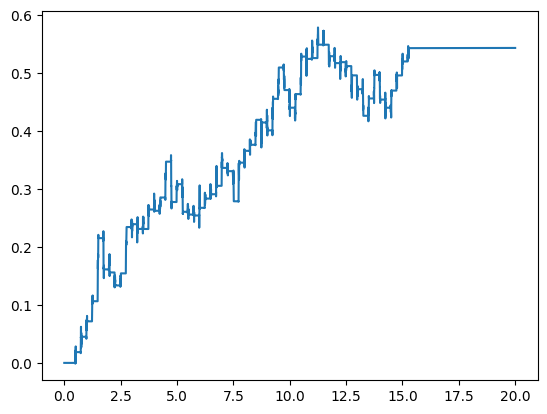

In [41]:
plt.plot(sol.t, sol.y[0])

In [25]:
from multiprocessing import Process
from functools import partial

def integrate(w0, DeltaT, seed):

    pre_spike_idxs = [int(t_start/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
    pre_spike_times = times[pre_spike_idxs]

    post_spike_idxs = [int((t_start-DeltaT)/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
    post_spike_times = times[post_spike_idxs]

    calcium_array = get_calcium_array(times, pre_spike_times, post_spike_times)

    rng = np.random.default_rng(seed=seed)
    random_normal = rng.normal(size=len(calcium_array))

    return (w0, DeltaT, seed, solve_ivp(dwdt, (0, T), (w0,), max_step=dt, first_step=dt, atol=1, rtol=1, args=(calcium_array, random_normal)))

In [48]:
seeds = np.random.randint(0, 1000, 30)
DeltaTs = np.linspace(-0.1, 0.1, 3)
w0s = (0., 1.)

integrations = []
for w0 in w0s:
    for DeltaT in DeltaTs:
        for seed in seeds:
            integrations.append((w0, DeltaT, seed))

results = []

pool = Pool()
results = pool.starmap(integrate, integrations)

In [50]:
map_from_w0_to_index = {w0:i for i,w0 in enumerate(w0s)}
map_from_DeltaT_to_index = {DeltaT:i for i,DeltaT in enumerate(DeltaTs)}
map_from_seed_to_index = {seed:i for i,seed in enumerate(seeds)}

ordered_results = np.zeros((len(w0s), len(DeltaTs), len(seeds)))

for result in results:
    
    w0_index = map_from_w0_to_index[result[0]]
    DeltaT_index = map_from_DeltaT_to_index[result[1]]
    seed_index = map_from_seed_to_index[result[2]]
    ordered_results[w0_index, DeltaT_index, seed_index] = result[3].y[0, -1]

In [51]:
syn_str = []
syn_str_err = []

for i, DeltaT in enumerate(DeltaTs):

    average0 = (ordered_results[0, i]>0.5).mean()
    average1 = (ordered_results[1, i]<0.5).mean()

    #x = (cond_up + (cond_up - 1.)*(init_down*(np.abs(average0) -1.) - (1.-init_down)*np.abs(average1)))/((1.-init_down)*cond_up + init_down)
    x = ((1-average0)*init_down + average1*(1-init_down) + cond_up*(average0*init_down + (1-average1)*(1-init_down)))/(init_down + (1-init_down)*cond_up)
    xerr = (cond_up - 1.)*(np.sqrt((init_down*average0*(1.-average1) + (1.-init_down)*np.abs(average1)*(1.-np.abs(average1)))/len(seeds)))

    syn_str.append(x)
    syn_str_err.append(xerr)

<ErrorbarContainer object of 3 artists>

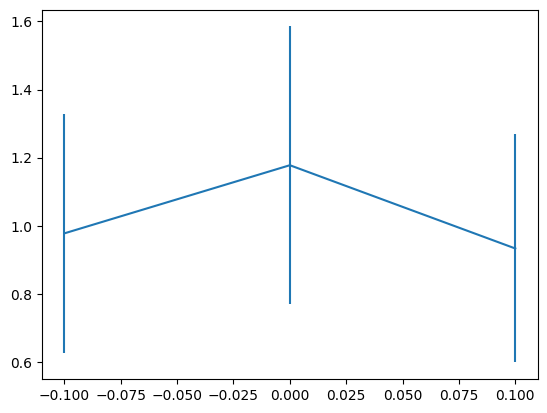

In [52]:
plt.errorbar(DeltaTs, syn_str, syn_str_err)

In [37]:
DeltaTs = np.linspace(-0.1, 0.1, 40)


T = 5 # s
dt = 1e-3 # s

rate = 1 # Hz
n_presentations = 3

t_start = 0.4 # s

times = np.arange(0, T+dt, dt)

w0 = 0.5

dw = []

for DeltaT in tqdm(DeltaTs):

    pre_spike_idxs = [int(t_start/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
    pre_spike_times = times[pre_spike_idxs]

    post_spike_idxs = [int((t_start-DeltaT)/dt) + i*int(1./(rate*dt)) for i in range(n_presentations)]
    post_spike_times = times[post_spike_idxs]

    calcium_array = get_calcium_array(times, pre_spike_times, post_spike_times)

    sol = solve_ivp(dwdt, (0, T), (w0,), max_step=dt, first_step=dt, atol=1, rtol=1)
    dw.append(sol.y[0, -1] - w0)

100%|██████████| 40/40 [00:14<00:00,  2.77it/s]


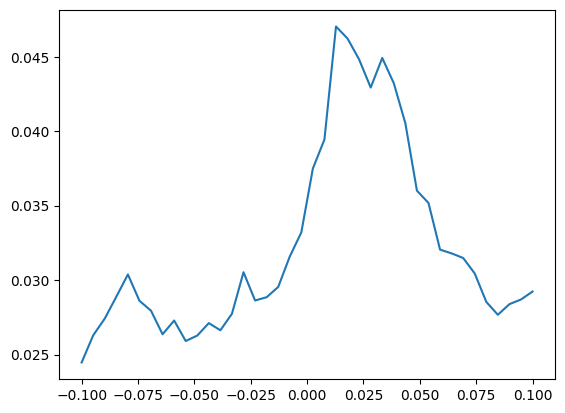

In [38]:
plt.plot(DeltaTs, dw)

## Recover the BCM curve (Figure S5)

In [ ]:
Cs = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
rates = np.linspace(0, 50, 20)

BCM_curves = np.zeros((len(C), len(rates)))

for i, C in enumerate(Cs):

    for j, rate in enumerate(rates):

        ...

        BCM_curves[i,j] = ...


## Question: is the model equivalent to the *theoretical* STDP?